# Eksplorasi Data (Exploratory Data Analysis)

## Latar Belakang

Sebelum data mentah diproses lebih lanjut, perlu dilakukan eksplorasi untuk memahami karakteristik dan kualitasnya. Tahap eksplorasi data (Exploratory Data Analysis/EDA) berfungsi sebagai dasar empiris dalam menentukan keputusan pemrosesan, sehingga langkah pembersihan dan penyaringan yang diambil pada tahap berikutnya berlandaskan kondisi data yang sebenarnya, bukan asumsi.

## Tujuan

Tahap ini bertujuan mengeksplorasi 2.000 artikel hasil pengumpulan data (`data/raw/articles.csv`) untuk mengidentifikasi pola dan potensi persoalan, seperti distribusi artikel antarkategori, sebaran panjang artikel, serta keberadaan artikel yang terlalu pendek maupun duplikat. Eksplorasi ini bersifat analisis semata dan tidak mengubah data; pemrosesan yang sesungguhnya dilakukan pada notebook terpisah setelah temuan EDA diperoleh. Seluruh visualisasi yang dihasilkan disimpan pada folder `reports/figures/` sebagai dokumentasi.

In [1]:
!pip install -q pandas matplotlib seaborn

## Persiapan dan Pemuatan Data

In [1]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def find_project_root():
    cwd = Path.cwd().resolve()
    if (cwd / "data").exists() and (cwd / "notebooks").exists():
        return cwd
    for parent in cwd.parents:
        if (parent / "data").exists() and (parent / "notebooks").exists():
            return parent
    return cwd

PROJECT_ROOT = find_project_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_RAW / "articles.csv")
print(f"Loaded {len(df)} artikel dari {DATA_RAW / 'articles.csv'}")

Loaded 2000 artikel dari C:\Users\user\news-rag-project\data\raw\articles.csv


Tahap ini menyiapkan pustaka yang dibutuhkan untuk analisis dan visualisasi, yaitu `pandas` dan `numpy` untuk pengolahan data serta `matplotlib` dan `seaborn` untuk pembuatan grafik. Lokasi root proyek dideteksi secara otomatis agar jalur berkas tetap konsisten, dan folder `reports/figures` disiapkan sebagai tempat penyimpanan visualisasi. Selanjutnya, data hasil pengumpulan dimuat dari `data/raw/articles.csv` untuk dieksplorasi.

## Struktur & Tipe Data

In [2]:
print(f"Shape : {df.shape}")
print(f"Kolom : {list(df.columns)}")
print(f"Memory: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB\n")
df.info()
print("\n--- Head ---")
df.head(3)

Shape : (2000, 6)
Kolom : ['article_id', 'judul', 'isi', 'kategori', 'url', 'tanggal']
Memory: 5.81 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   article_id  2000 non-null   object
 1   judul       2000 non-null   object
 2   isi         2000 non-null   object
 3   kategori    2000 non-null   object
 4   url         2000 non-null   object
 5   tanggal     1996 non-null   object
dtypes: object(6)
memory usage: 93.9+ KB

--- Head ---


,article_id,judul,isi,kategori,url,tanggal
0,b5a62b697be0,"Prancis Dilanda Gelombang Panas, 7 Orang Tewas",Gelombang panas melanda wilayah Eropa bagian b...,news,https://news.detik.com/internasional/d-8505869...,"Selasa, 26 Mei 2026 15:30 WIB"
1,4b31cac3925f,"Drone Rusia Lukai 2 Orang, Rumania Akui Tak Se...",Sedikitnya dua orang mengalami luka-luka di Ru...,news,https://news.detik.com/internasional/d-8509864...,"Jumat, 29 Mei 2026 16:43 WIB"
2,76073dd9a247,"Diduga Kelelahan, Driver Ojol Ditemukan Terkap...",Seorang driver ojek online (ojol) ditemukan te...,news,https://news.detik.com/berita/d-8509077/diduga...,"Jumat, 29 Mei 2026 09:41 WIB"


Pemeriksaan struktur memastikan data termuat sesuai harapan. Dataset terdiri dari 2.000 baris dan 6 kolom, `article_id`, `judul`, `isi`, `kategori`, `url`, dan `tanggal`, yang seluruhnya bertipe teks (object). Seluruh kolom terisi penuh, kecuali `tanggal` yang memiliki sedikit nilai kosong (1.996 dari 2.000 terisi). Temuan ini menunjukkan data secara umum lengkap, dengan catatan kecil pada kolom tanggal yang perlu diperhatikan pada tahap pemrosesan.

## Missing Values

In [3]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({"null_count": miss, "null_pct": miss_pct})
print(miss_df)

            null_count  null_pct
article_id           0       0.0
judul                0       0.0
isi                  0       0.0
kategori             0       0.0
url                  0       0.0
tanggal              4       0.2


Pemeriksaan nilai kosong dilakukan secara menyeluruh pada setiap kolom. Hasilnya, kolom inti yang dibutuhkan untuk pemodelan, terutama `judul`, `isi`, dan `kategori`, terisi sepenuhnya tanpa nilai kosong. Nilai kosong hanya ditemukan pada kolom `tanggal` sebanyak 4 baris (0,2%), yang jumlahnya sangat kecil dan tidak berpengaruh pada komponen utama sistem karena tanggal hanya berperan sebagai metadata pelengkap.

## Duplikat

In [4]:
print("Duplikat per kolom:")
for col in ["article_id", "url", "judul", "isi"]:
    print(f"  {col:<12}: {df[col].duplicated().sum()}")

# Detail duplikat isi
dup_isi = df[df["isi"].duplicated(keep=False)]
print(f"\nDuplikat isi: {len(dup_isi)} baris dalam {dup_isi['isi'].nunique()} grup")
if len(dup_isi) > 0:
    cross = dup_isi.groupby("isi")["kategori"].nunique()
    print(f"Grup duplikat lintas kategori: {(cross > 1).sum()}")

Duplikat per kolom:
  article_id  : 0
  url         : 0
  judul       : 2
  isi         : 47

Duplikat isi: 62 baris dalam 15 grup
Grup duplikat lintas kategori: 0


Pemeriksaan duplikasi dilakukan pada beberapa kolom untuk menilai keunikan data. Berdasarkan `article_id` dan `url`, tidak ditemukan duplikat sama sekali, yang menandakan setiap artikel berasal dari tautan yang berbeda. Namun, ditemukan 2 judul yang sama serta 47 isi yang terduplikasi (mencakup 62 baris dalam 15 grup). Seluruh duplikasi isi terjadi di dalam kategori yang sama, bukan lintas kategori, sehingga kemungkinan besar berasal dari artikel yang tampil berulang pada satu kanal. Temuan ini menjadi dasar perlunya penghapusan duplikat berdasarkan isi pada tahap pemrosesan.

## Distribusi Kategori

kategori
news       400
finance    400
sport      400
inet       400
health     400
Name: count, dtype: int64

Balance ratio (min/max): 1.00


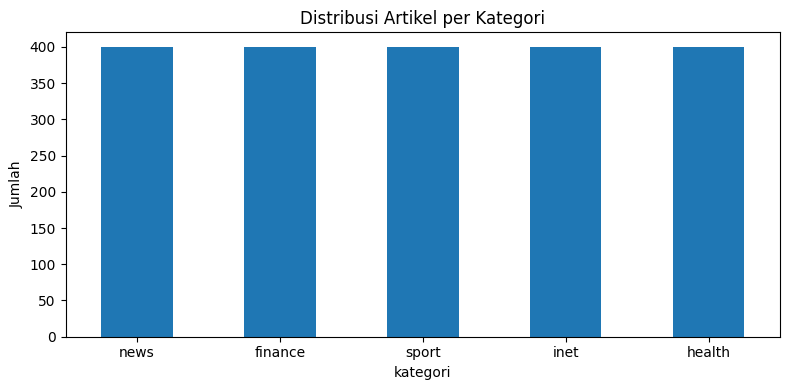

In [5]:
vc = df["kategori"].value_counts()
print(vc)
print(f"\nBalance ratio (min/max): {vc.min()/vc.max():.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
vc.plot(kind="bar", ax=ax, color="#1f77b4")
ax.set_title("Distribusi Artikel per Kategori")
ax.set_ylabel("Jumlah")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_kategori_dist.png", dpi=100, bbox_inches="tight")
plt.show()

Distribusi jumlah artikel pada setiap kategori divisualisasikan untuk menilai keseimbangan data. Hasilnya menunjukkan distribusi yang sempurna seimbang, yaitu tepat 400 artikel pada masing-masing dari lima kategori, dengan rasio keseimbangan (min/maks) sebesar 1,00. Keseimbangan ini merupakan kondisi ideal bagi pelatihan model klasifikasi kategori, karena tidak ada kelas yang terlalu dominan maupun terlalu sedikit sehingga model dapat belajar secara adil pada seluruh kelas. Hal ini karena kammi sengaja scrap data secara simbang dari semua kategori, nantinya saat preprocess, mungkin ada perubahan sedikit di distribusi supaya tidak ada duplikat dan missing value

## Analisis Panjang Teks

In [6]:
df["n_words"] = df["isi"].str.split().str.len()
df["n_chars"] = df["isi"].str.len()

print("--- Statistik panjang (kata) ---")
print(df["n_words"].describe().round(1))

print("\n--- Per kategori (kata) ---")
print(df.groupby("kategori")["n_words"].describe()[["mean", "50%", "min", "max"]].round(0).to_string())

--- Statistik panjang (kata) ---
count    2000.0
mean      332.7
std       195.1
min         3.0
25%       221.0
50%       304.0
75%       420.0
max      2051.0
Name: n_words, dtype: float64

--- Per kategori (kata) ---
           mean    50%   min     max
kategori                            
finance   341.0  300.0  15.0  1715.0
health    335.0  324.0  17.0  1070.0
inet      361.0  358.0   3.0  2051.0
news      376.0  318.0  76.0  1595.0
sport     251.0  236.0  19.0   708.0


Panjang artikel dianalisis berdasarkan jumlah kata untuk memahami sebaran dan menemukan anomali. Secara keseluruhan, artikel memiliki rata-rata sekitar 333 kata dengan median 304 kata, namun rentangnya sangat lebar, dari hanya 3 kata hingga lebih dari 2.000 kata. Distribusinya condong ke kanan (right-skewed): mayoritas artikel berada pada kisaran wajar, dengan sebagian kecil artikel yang sangat panjang membentuk ekor distribusi.


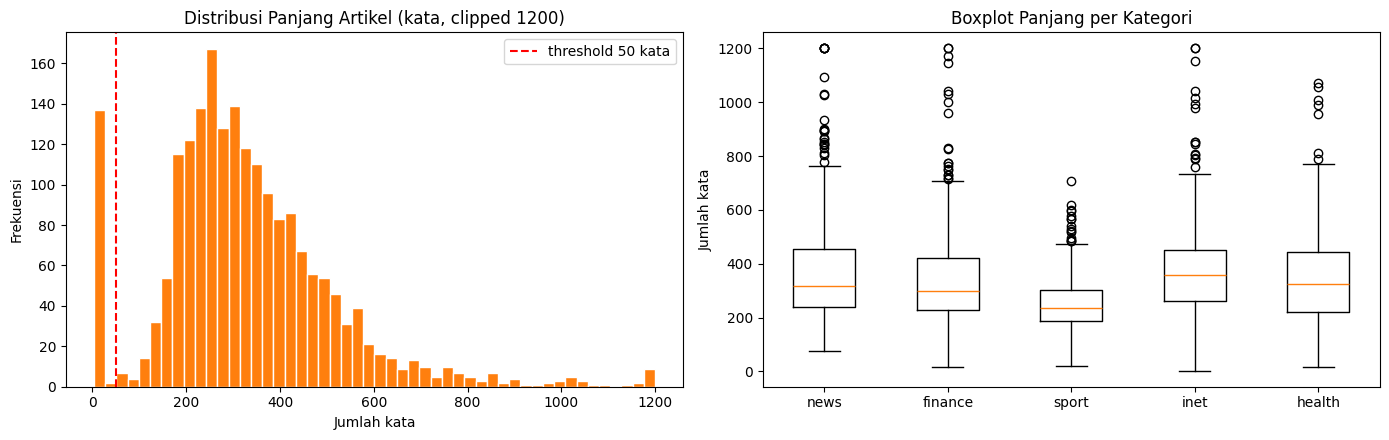

In [7]:
# Visualisasi panjang teks
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Histogram
axes[0].hist(df["n_words"].clip(upper=1200), bins=50, color="#ff7f0e", edgecolor="white")
axes[0].axvline(50, color="red", linestyle="--", label="threshold 50 kata")
axes[0].set_title("Distribusi Panjang Artikel (kata, clipped 1200)")
axes[0].set_xlabel("Jumlah kata")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()

# Boxplot per kategori
cats = df["kategori"].unique()
data = [df[df["kategori"] == c]["n_words"].clip(upper=1200) for c in cats]
axes[1].boxplot(data, tick_labels=cats)
axes[1].set_title("Boxplot Panjang per Kategori")
axes[1].set_ylabel("Jumlah kata")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_panjang_teks.png", dpi=100, bbox_inches="tight")
plt.show()

Histogram memperlihatkan adanya lonjakan artikel yang sangat pendek di dekat angka nol, jauh di bawah garis ambang 50 kata. Artikel sependek ini umumnya tidak memuat konten yang memadai dan berpotensi menjadi noise, sehingga temuan ini memperkuat perlunya penyaringan artikel berdasarkan panjang minimum pada tahap pemrosesan. Boxplot per kategori menunjukkan variasi antarkanal, di mana kategori sport cenderung memiliki artikel terpendek sementara news dan inet cenderung lebih panjang.

## Outlier Panjang (kandidat drop)

In [8]:
print("Artikel pendek (kandidat drop):")
for t in [30, 50, 75, 100]:
    n = (df["n_words"] < t).sum()
    print(f"  < {t:>3} kata : {n:>4} ({n/len(df)*100:.1f}%)")

print("\nArtikel sangat panjang:")
for t in [1000, 1500, 2000]:
    n = (df["n_words"] > t).sum()
    print(f"  > {t} kata : {n:>4} ({n/len(df)*100:.1f}%)")

print("\n--- Artikel pendek (<50 kata) per kategori ---")
print(df[df["n_words"] < 50]["kategori"].value_counts())

print("\n--- Contoh 5 artikel terpendek ---")
for _, r in df.nsmallest(5, "n_words").iterrows():
    print(f"  [{r['kategori']}] ({r['n_words']}kt) {r['judul'][:50]} | isi: '{r['isi'][:50]}'")

Artikel pendek (kandidat drop):
  <  30 kata :  137 (6.9%)
  <  50 kata :  139 (7.0%)
  <  75 kata :  146 (7.3%)
  < 100 kata :  151 (7.5%)

Artikel sangat panjang:
  > 1000 kata :   23 (1.1%)
  > 1500 kata :    4 (0.2%)
  > 2000 kata :    1 (0.1%)

--- Artikel pendek (<50 kata) per kategori ---
kategori
health     55
inet       39
finance    24
sport      21
Name: count, dtype: int64

--- Contoh 5 artikel terpendek ---
  [inet] (3kt) AI Kamera Sony Xperia 1 VIII Jadi Bahan Meme Kocak | isi: 'Pool - detikInet'
  [inet] (3kt) Meme Arsenal Juara, Gooners Ketawa Puas Fans City  | isi: 'Pool - detikInet'
  [inet] (3kt) 10 Foto Momen Langka yang Mungkin Tak Akan Terjadi | isi: 'Pool - detikInet'
  [inet] (3kt) Erling Haaland Ucap Selamat ke Arsenal, Dibalas Me | isi: 'Pool - detikInet'
  [inet] (3kt) Momen Sial Tingkat Dewa, Orang-orang Ini Apes Maks | isi: 'Pool - detikInet'


Untuk menentukan ambang penyaringan, jumlah artikel pendek dihitung pada beberapa nilai ambang. Terdapat 137 artikel (6,9%) dengan panjang di bawah 30 kata, dan angka ini nyaris tidak bertambah ketika ambang dinaikkan, hanya menjadi 139 artikel pada ambang 50 kata dan 151 artikel pada 100 kata. Pola ini mengindikasikan adanya kelompok artikel sangat pendek yang terpisah jelas dari artikel normal: di antara ambang 30 hingga 100 kata nyaris tidak ada artikel, yang menandakan adanya celah alami pada distribusi panjang. Karena itu ambang 50 kata dipilih sebagai batas penyaringan; nilai ini berada tepat di celah tersebut, di atas kelompok artikel sangat pendek namun di bawah titik mulai menumpuknya berita normal, sehingga relatif tidak sensitif terhadap pergeseran kecil dan motong noise tanpa membuang berita yang sah.

Pemeriksaan terhadap contoh artikel terpendek mengungkap bahwa artikel-artikel tersebut bukan berita sesungguhnya, melainkan halaman galeri foto atau konten meme yang isinya hanya berupa placeholder seperti "Pool - detikInet" dengan panjang 3 kata, sehingga memperkuat alasan untuk menyaringnya. Sebaran artikel pendek terbanyak terdapat pada kategori health dan inet. Sebaliknya, artikel yang sangat panjang (>1000 kata) hanya berjumlah 23 (1,1%) dan masih merupakan artikel sah, sehingga tidak perlu dibuang.

## Deteksi Noise Residu

In [9]:
noise_patterns = {
    "[Gambas:...] (video embed)" : r"\[Gambas",
    "Lihat juga Video"           : r"Lihat juga Video",
    "Simak juga Video"           : r"Simak juga Video",
    "Baca juga"                  : r"Baca juga",
    "Saksikan"                   : r"Saksikan",
    "ADVERTISEMENT"              : r"ADVERTISEMENT",
    "SCROLL TO CONTINUE"         : r"SCROLL TO CONTINUE",
}

print("Pattern noise dalam isi artikel:")
for name, pat in noise_patterns.items():
    n = df["isi"].str.contains(pat, case=False, na=False, regex=True).sum()
    print(f"  {name:<28}: {n:>4} artikel ({n/len(df)*100:.1f}%)")

# Contoh konteks noise terbesar (Gambas)
print("\n--- Contoh konteks [Gambas:Video] ---")
gambas = df[df["isi"].str.contains(r"\[Gambas", na=False, regex=True)]
for _, r in gambas.head(2).iterrows():
    idx = r["isi"].find("[Gambas")
    print(f"  ...{r['isi'][max(0,idx-70):idx+30]}...")

Pattern noise dalam isi artikel:
  [Gambas:...] (video embed)  :  414 artikel (20.7%)
  Lihat juga Video            :  121 artikel (6.0%)
  Simak juga Video            :  101 artikel (5.1%)
  Baca juga                   :    7 artikel (0.4%)
  Saksikan                    :   25 artikel (1.2%)
  ADVERTISEMENT               :    0 artikel (0.0%)
  SCROLL TO CONTINUE          :    0 artikel (0.0%)

--- Contoh konteks [Gambas:Video] ---
  ...mak juga Video 'Panas Ekstrem di India Bikin Warga-Kambing Masuk RS': [Gambas:Video 20detik]...
  ...omen Sopir Diduga Taksi Online Ngamuk hingga Rusak Mobil di Tol JORR" [Gambas:Video 20detik]...


Selain artikel pendek, isi artikel juga diperiksa terhadap pola teks yang bukan merupakan konten berita, seperti penanda video tersemat dan ajakan navigasi. Pola yang paling banyak ditemukan adalah penanda video embed `[Gambas:Video ...]` pada 414 artikel (20,7%), diikuti frasa "Lihat juga Video" (6,0%) dan "Simak juga Video" (5,1%), sementara pola lain seperti "Baca juga" dan "Saksikan" muncul dalam jumlah kecil. Pola "ADVERTISEMENT" dan "SCROLL TO CONTINUE" tidak ditemukan, kemungkinan karena sudah tersaring pada saat ekstraksi.

Pemeriksaan konteks menunjukkan penanda-penanda ini umumnya menyisip di tengah teks berita, sehingga ikut terbawa saat isi diekstraksi. Karena cukup banyak (terutama `[Gambas:...]` yang muncul pada satu dari lima artikel), pola-pola ini perlu dibersihkan pada tahap pemrosesan agar isi artikel benar-benar bersih dari sisa elemen non-konten.

## Analisis Tanggal

In [10]:
print(f"Null tanggal: {df['tanggal'].isnull().sum()}")
print(f"\nSample format tanggal:")
for t in df["tanggal"].dropna().head(3):
    print(f"  {t}")

# Format Detik: "Jumat, 29 Mei 2026 20:11 WIB"
print(f"\nCatatan: tanggal gak dipakai buat classification/sentiment,")
print(f"jadi null tanggal aman dibiarkan.")

Null tanggal: 4

Sample format tanggal:
  Selasa, 26 Mei 2026 15:30 WIB
  Jumat, 29 Mei 2026 16:43 WIB
  Jumat, 29 Mei 2026 09:41 WIB

Catatan: tanggal gak dipakai buat classification/sentiment,
jadi null tanggal aman dibiarkan.


Kolom tanggal diperiksa untuk memahami format dan kelengkapannya. Terdapat 4 nilai kosong, dan format yang digunakan konsisten mengikuti pola Detik, yaitu "Hari, DD Bulan YYYY HH:MM WIB" (misalnya "Selasa, 26 Mei 2026 15:30 WIB"). Karena tanggal hanya berperan sebagai metadata pelengkap dan tidak digunakan dalam proses klasifikasi maupun analisis sentimen, sejumlah kecil nilai kosong tersebut dapat dibiarkan tanpa memengaruhi komponen utama sistem.

In [11]:
bulan = {"Januari":1,"Februari":2,"Maret":3,"April":4,"Mei":5,"Juni":6,
         "Juli":7,"Agustus":8,"September":9,"Oktober":10,"November":11,"Desember":12}

def parse_tgl(t):
    m = re.search(r"(\d{1,2})\s+(\w+)\s+(\d{4})", str(t))
    if not m or m.group(2) not in bulan:
        return pd.NaT
    d, b, y = m.groups()
    return pd.Timestamp(int(y), bulan[b], int(d))

dates = df["tanggal"].dropna().map(parse_tgl).dropna()
print(f"Rentang tanggal: {dates.min():%d %B %Y} s/d {dates.max():%d %B %Y}")
print(f"Tanggal valid  : {len(dates)} dari {len(df)} artikel")

Rentang tanggal: 01 May 2026 s/d 29 May 2026
Tanggal valid  : 1927 dari 2000 artikel


Tanggal publikasi diuraikan dari format teks Detik untuk mengetahui cakupan periode data. Hasilnya menunjukkan seluruh artikel berasal dari rentang 1 Mei 2026 hingga 29 Mei 2026 (1.927 dari 2.000 artikel memiliki tanggal valid). Periode yang relatif singkat ini sekaligus menjadi batasan (limitasi) sistem: karena basis pengetahuan RAG hanya memuat berita dalam rentang tersebut, sistem hanya mampu menjawab pertanyaan seputar peristiwa yang terjadi pada periode itu dan tidak memiliki informasi mengenai kejadian di luar rentang waktu data.

## Inspeksi Sampel (1 per kategori)

In [13]:
for cat in sorted(df["kategori"].unique()):
    s = df[(df["kategori"] == cat) & (df["n_words"] >= 150)].iloc[0]
    print(f"=== [{cat}] {s['judul']}")
    print(f"    Tanggal: {s['tanggal']}")
    print(f"    Panjang: {s['n_words']} kata")
    print(f"    Isi    : {s['isi'][:200]}...")
    print()

=== [finance] KSP Cek Sekolah Rakyat Jawa Barat II, Progres Pembangunan Lampaui Target
    Tanggal: Rabu, 20 Mei 2026 15:42 WIB
    Panjang: 390 kata
    Isi    : Kepala Staf Kepresidenan (KSP) Dudung Abdurachman meninjau secara langsung progres pembangunan Sekolah Rakyat Provinsi Jawa Barat II di Cikarang, Kabupaten Bekasi, Senin (18/5). Proyek yang dibangun o...

=== [health] Ebola Kini 'Selevel' COVID-19 di Awal Pandemi, Ini Antisipasi Kemenkes RI
    Tanggal: Sabtu, 23 Mei 2026 09:04 WIB
    Panjang: 286 kata
    Isi    : Kementerian Kesehatan (Kemenkes RI) mengaku cukup percaya diri dalam menghadapi ancaman Ebola yang belakangan ini menggemparkan dunia. Saat ini, World Health Organization (WHO) telah menetapkan status...

=== [inet] Starship V3 SpaceX Meledak Usai Uji Tebang, Alasannya Mengejutkan
    Tanggal: Senin, 25 Mei 2026 13:21 WIB
    Panjang: 191 kata
    Isi    : Pesawat luar angkasa Starship V3 sukses uji terbang perdana keliling Bumi, lalu meledak saat mendarat. Jawaba

Sebagai pemeriksaan kualitatif terakhir, satu artikel representatif (dengan panjang memadai) ditinjau dari setiap kategori. Hasilnya menunjukkan isi artikel terekstraksi dengan baik berupa teks berita yang utuh, koheren, dan relevan dengan kategorinya, tanpa potongan kalimat yang terputus maupun konten yang tidak relevan. Pemeriksaan ini menegaskan bahwa data hasil pengumpulan secara umum sudah bersih dan layak untuk dilanjutkan ke tahap pemrosesan.

## Rencana Pemrosesan Data

Berdasarkan temuan EDA, ditetapkan langkah-langkah pemrosesan berikut untuk membersihkan dan menyiapkan data:

1. **Penghapusan noise**, membuang pola non-konten yang teridentifikasi pada isi artikel, yaitu penanda video tersemat `[Gambas:Video ...]`, serta frasa "Lihat juga Video", "Simak juga Video", dan "Baca juga".
2. **Normalisasi whitespace**, merapikan spasi dan baris baru yang berlebih.
3. **Penghitungan ulang jumlah kata**, menghitung kembali panjang artikel setelah noise dihapus.
4. **Penyaringan artikel pendek**, membuang artikel dengan panjang di bawah 50 kata (sekitar 139 artikel, termasuk galeri foto berisi placeholder "Pool - detikInet").
5. **Penghapusan duplikat**, menghapus duplikat berdasarkan isi (sekitar 47) dan judul (sekitar 2) dengan mempertahankan kemunculan pertama (keep-first).
6. **Penanganan tanggal kosong**, nilai tanggal yang kosong dibiarkan karena tidak digunakan untuk klasifikasi, analisis sentimen, maupun RAG.

Beberapa langkah pra pemrosesan klasik sengaja tidak dilakukan, yaitu stemming, penghapusan stopword, dan lowercasing agresif. Alasannya, model IndoBERT bersifat kontekstual dan case-aware sehingga justru memanfaatkan bentuk kata dan kapitalisasi asli, sementara komponen RAG membutuhkan teks natural yang utuh untuk menghasilkan embedding dan konteks yang baik bagi LLM.

## Penutup

Tahap eksplorasi data telah selesai dan menghasilkan pemahaman menyeluruh atas karakteristik serta kualitas data, yang menjadi dasar penetapan langkah pemrosesan di atas. Visualisasi pendukung disimpan pada folder `reports/figures/` (`eda_kategori_dist.png` dan `eda_panjang_teks.png`). Tahap berikutnya membahas pemrosesan data, yang menerapkan langkah pembersihan dan penyaringan tersebut sebelum data digunakan untuk pemodelan.